<a href="https://colab.research.google.com/github/PutriBalqis134/FYP-HNSCC/blob/main/Single_Omic_Model_CNV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (Input, Dense, Embedding, Flatten, Concatenate, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


#Dataset Input

In [ ]:
# Load sample info for ID mapping
sample_info = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/sample_info_updated.csv')
print("Sample Info Shape:", sample_info.shape)
display(sample_info.head())

Sample Info Shape: (120, 2)


,depmapId,cellLineDisplayName
0,ACH-000740,A253
1,ACH-002212,BB30HNC
2,ACH-002213,BB49HNC
3,ACH-000548,BHY
4,ACH-001331,BICR10


In [ ]:
# Load CNV dataset
cnv = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/CNV_HNSCC_filtered.csv')
cnv = cnv.set_index("depmapId")

print("Copy Number Variation Data Shape:", cnv.shape)
display(cnv.head())


Copy Number Variation Data Shape: (62, 16383)


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,CASP4 (837),AP2A1 (160),ZNF585A (199704),FUT11 (170384),SMIM10L2B (644596),Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
depmapId,,,,,,,,,,,,,,,,,,,,,
ACH-000740,0.728559,0.669183,1.503568,0.781068,0.790443,0.779883,0.758218,1.170253,0.813774,0.783182,...,0.722484,1.126864,1.030269,0.764863,0.904255,0,0,0,0,0
ACH-000548,0.662364,0.621770,1.997582,0.827255,0.842007,0.957908,0.789218,0.835493,1.186515,1.184735,...,1.165758,0.973956,0.922237,1.382828,0.873109,0,0,0,0,0
ACH-000503,0.798144,0.842718,1.347356,0.867580,0.882615,0.983850,0.786156,0.780690,0.998950,0.993453,...,0.784307,1.201555,0.750856,0.796256,0.706318,0,0,0,0,0
ACH-000228,0.521923,0.542177,1.421429,1.063213,1.034554,1.051610,1.034337,1.055296,1.072412,1.098140,...,0.565026,0.958961,0.886782,1.003044,0.842396,0,0,0,0,0
ACH-000771,1.018873,0.951379,1.523361,0.990714,0.984123,0.987912,0.945265,0.998935,0.992171,1.025340,...,0.984264,1.028710,0.971424,0.990663,1.003113,0,0,0,0,0


In [ ]:
# Load drug response dataset (logIC50)
ic50_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/HNSCC_IC50.csv')
print("GDSC IC50 Shape:", ic50_df.shape)
display(ic50_df.head())

GDSC IC50 Shape: (9408, 12)


,Drug Name,Drug ID,cellLineDisplayName,Cosmic ID,TCGA Classification,Tissue,Tissue Sub-type,IC50,AUC,Max Conc,RMSE,Z score
0,Camptothecin,1003,BB30HNC,753531,HNSC,aero_digestive_tract,head_and_neck,-4.016599,0.729320,0.1,0.121919,-0.956747
1,Camptothecin,1003,BB49HNC,753532,HNSC,aero_digestive_tract,head_and_neck,-2.024280,0.867884,0.1,0.109995,0.128007
2,Camptothecin,1003,BHY,753535,HNSC,aero_digestive_tract,head_and_neck,-2.081150,0.872193,0.1,0.068698,0.097043
3,Camptothecin,1003,Ca922,753538,HNSC,aero_digestive_tract,head_and_neck,-3.523805,0.764404,0.1,0.095041,-0.688436
4,Camptothecin,1003,CAL33,753541,HNSC,aero_digestive_tract,head_and_neck,-3.711201,0.746475,0.1,0.094559,-0.790468


#Data Preprocess

In [ ]:
#build mapping table to align key ids from all datasets
map_df = sample_info[["depmapId", "cellLineDisplayName"]].drop_duplicates()

#merge ic50 dataset with sample_info to align depmapId
ic50 = ic50_df.merge(map_df, on="cellLineDisplayName", how="inner")

ic50 = ic50[["depmapId", "Drug Name", "IC50"]]

print(ic50_df.shape)
print(ic50.shape)
ic50.head()

(9408, 12)
(9127, 3)


,depmapId,Drug Name,IC50
0,ACH-002212,Camptothecin,-4.016599
1,ACH-002213,Camptothecin,-2.024280
2,ACH-000548,Camptothecin,-2.081150
3,ACH-002043,Camptothecin,-3.523805
4,ACH-000518,Camptothecin,-3.711201


In [ ]:
#merge cnv dataset with mapped IC50 dataset
merged_df = pd.merge(
    ic50,
    cnv,
    left_on='depmapId',
    right_on='depmapId',
    how='inner')

print("Merged CNV + IC50 Shape:", merged_df.shape)
display(merged_df.head())

Merged CNV + IC50 Shape: (4062, 16386)


,depmapId,Drug Name,IC50,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),...,CASP4 (837),AP2A1 (160),ZNF585A (199704),FUT11 (170384),SMIM10L2B (644596),Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383
0,ACH-000548,Camptothecin,-2.081150,0.662364,0.621770,1.997582,0.827255,0.842007,0.957908,0.789218,...,1.165758,0.973956,0.922237,1.382828,0.873109,0,0,0,0,0
1,ACH-000548,Camptothecin,-2.081150,0.662364,0.621770,1.997582,0.827255,0.842007,0.957908,0.789218,...,1.165758,0.973956,0.922237,1.382828,0.873109,0,0,0,0,0
2,ACH-002043,Camptothecin,-3.523805,0.389933,0.429828,1.603335,0.847949,0.820926,0.813093,0.843225,...,1.190135,0.845262,0.878985,1.269776,0.996553,0,0,0,0,0
3,ACH-002043,Camptothecin,-3.523805,0.389933,0.429828,1.603335,0.847949,0.820926,0.813093,0.843225,...,1.190135,0.845262,0.878985,1.269776,0.996553,0,0,0,0,0
4,ACH-002045,Camptothecin,-1.717440,0.398207,0.427551,1.274812,1.216686,1.218675,0.836137,0.801949,...,0.780852,0.852773,1.038201,1.380195,0.768073,0,0,0,0,0


In [ ]:
# Drop columns that are entirely NaN from merged_df
merged_df_cleaned = merged_df.dropna(axis=1, how='all')

# Prepare X (features) and y (target)
# Select only numerical columns (genes expression) as features
feature_columns = merged_df_cleaned.select_dtypes(include=[np.number, bool]).columns.tolist()

# Ensure 'IC50' and 'depmapId' is not in feature_columns if it somehow got included
if 'IC50' in feature_columns:
    feature_columns.remove('IC50')

if 'depmapId' in feature_columns:
    feature_columns.remove('depmapId')

X = merged_df_cleaned[feature_columns].values
y = merged_df_cleaned['IC50'].values

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

Final X shape: (4062, 16383)
Final y shape: (4062,)


In [ ]:
#transform 'Drug Name' into 'Drug_ID' because string cannot be used directly as input
drug_encoder = LabelEncoder()

merged_df_cleaned["Drug_ID"] = drug_encoder.fit_transform(
    merged_df_cleaned["Drug Name"])

num_drugs = merged_df_cleaned["Drug_ID"].nunique()
print("Number of drugs:", num_drugs)

Number of drugs: 288


In [ ]:
#Filter out genes with >95% zero expression
zero_threshold = 0.95
zero_counts = (merged_df_cleaned[feature_columns] == 0).sum() / len(merged_df_cleaned)
keep_columns = zero_counts[zero_counts <= zero_threshold].index.tolist()

print(f"Original features: {len(feature_columns)}")
print(f"Features after removing high-zero columns: {len(keep_columns)}\n")

#CNV features
X_gene = merged_df_cleaned[keep_columns].values

#Drug IDs
X_drug = merged_df_cleaned["Drug_ID"].values

#Target
y = merged_df_cleaned["IC50"].values

print(X_gene.shape)
print(X_drug.shape)
print(y.shape)

Original features: 16383
Features after removing high-zero columns: 16052

(4062, 16052)
(4062,)
(4062,)


#Train-Test Split and Data Normalization

In [ ]:
# Split data into training and testing sets
indices = np.arange(len(X_gene))
(   X_gene_train,
    X_gene_test,
    X_drug_train,
    X_drug_test,
    y_train,
    y_test,
    train_idx,
    test_idx ) = train_test_split (X_gene,
                                   X_drug,
                                   y,
                                   indices,
                                   test_size=0.2,
                                   random_state=42)

# Data Normalization
scaler = StandardScaler()
X_gene_train = scaler.fit_transform(X_gene_train)
X_gene_test = scaler.transform(X_gene_test)

print("Data normalized successfully.")

Data normalized successfully.


In [ ]:
#select only top genes
selector = SelectKBest(score_func = f_regression, k=1000)

X_gene_train = selector.fit_transform(X_gene_train, y_train)
X_gene_test = selector.transform(X_gene_test)

print(X_gene_train.shape)

(3249, 1000)


#Build and Compile the Model

In [ ]:
#Gene branch
gene_input = Input(shape=(X_gene_train.shape[1],), name="Gene_Input")

gene_branch = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.001))(gene_input)

gene_branch = Dropout(0.3)(gene_branch)

In [ ]:
#Drug embedding branch
drug_input = Input(
    shape=(1,),
    name="Drug_Input")

drug_embedding = Embedding(
    input_dim=num_drugs,
    output_dim=32)(drug_input)

drug_embedding = Flatten()(drug_embedding)

In [ ]:
merged = Concatenate()(
    [gene_branch, drug_embedding])

In [ ]:
#Dense layer
merged = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001))(merged)

merged = Dropout(0.3)(merged)

In [ ]:
#output
output = Dense(1, activation="linear")(merged)

In [ ]:
model = Model(
    inputs=[gene_input, drug_input],
    outputs=output)

model.compile(
    optimizer=Adam(0.005),
    loss="mse",
    metrics=["mse"])

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Gene_Input          │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drug_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │    128,128 │ Gene_Input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │      9,216 │ Drug_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 160)       │          0 │ dropout_8[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │     10,304 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │         65 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,713 (577.00 KB)

 Trainable params: 147,713 (577.00 KB)

 Non-trainable params: 0 (0.00 B)

#Train the Model

In [ ]:
history = model.fit(
    [X_gene_train, X_drug_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

print("\nModel training complete with best weights restored.")

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 11.2921 - mse: 10.9180 - val_loss: 7.8089 - val_mse: 7.4104
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 6.3772 - mse: 5.9156 - val_loss: 3.9976 - val_mse: 3.4334
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7506 - mse: 3.1533 - val_loss: 2.9879 - val_mse: 2.3945
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0927 - mse: 2.5009 - val_loss: 2.1845 - val_mse: 1.5971
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5843 - mse: 2.0154 - val_loss: 1.9000 - val_mse: 1.3492
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.4521 - mse: 1.9184 - val_loss: 1.8659 - val_mse: 1.3459
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.2732 - mse: 1.7753 - val_loss: 1.6764 - val_mse: 1.1954
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.1852 - mse: 1.7163 - val_loss: 1.6773 - val_mse: 1.2211
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.

#Evaluate the Model

In [ ]:
# Make predictions on the test set
y_pred = model.predict([X_gene_test, X_drug_test])

# Evaluate the model on test data
mse = mean_squared_error(y_test, y_pred)
print("\nTest Loss (MSE): ", mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print("Test R-squared (R²): ", r2)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Test Loss (MSE):  1.1115763866236044
Test R-squared (R²):  0.8567486098776325


In [ ]:
# Get original test rows
test_df_original = merged_df_cleaned.iloc[test_idx].copy()

# Add actual and predicted values
test_df_original["actual_IC50"] = y_test
test_df_original["predicted_IC50"] = y_pred.flatten()

drug_r2_scores = []

MIN_SAMPLES = 3

for drug_name, drug_subset in test_df_original.groupby("Drug Name"):

    if len(drug_subset) >= MIN_SAMPLES:

        r2 = r2_score(
            drug_subset["actual_IC50"],
            drug_subset["predicted_IC50"])

        drug_r2_scores.append({
            "Drug Name": drug_name,
            "R²": r2,
            "n_test_samples": len(drug_subset)
            })

if len(drug_r2_scores) > 0:

    drug_r2_df = pd.DataFrame(drug_r2_scores)

    drug_r2_df = drug_r2_df.sort_values(
        by="R²",
        ascending=False)

    print("Top 3 drugs by R²:")
    display(drug_r2_df.head(3))

else:
    print("No drugs have at least", MIN_SAMPLES, "test samples.")

Top 3 drugs by R²:


,Drug Name,R²,n_test_samples
107,PFI3,0.924319,5
142,VX-11e,0.821472,4
77,Lenalidomide,0.796325,4


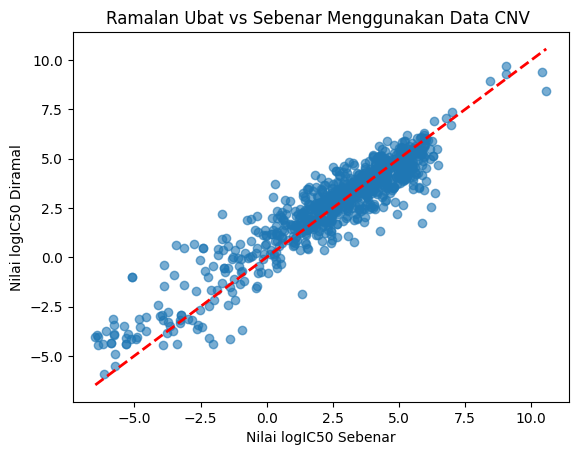

In [ ]:
import matplotlib.pyplot as plt

# Contoh untuk model Mutasi Gen
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)  # garis y=x untuk rujukan
plt.xlabel('Nilai logIC50 Sebenar')
plt.ylabel('Nilai logIC50 Diramal')
plt.title('Ramalan Ubat vs Sebenar Menggunakan Data CNV ')
plt.show()
